In [1]:
import torch
from simple_neural_mpc.robots import Unicycle
from simple_neural_mpc.neural_modeling.dataset import UnicycleDataset
from simple_neural_mpc.neural_modeling.dataset.datamodule import Datamodule
from simple_neural_mpc.utils import project_root
import numpy as np
from simple_neural_mpc.config.neural_config import DatasetConfig
from simple_neural_mpc.config.neural_config import TrainerConfig

np.set_printoptions(precision=3, suppress=True)

seed = 134
torch.random.manual_seed(seed)
np.random.seed(seed)

robot = Unicycle()
if DatasetConfig.name == "derivative":
    dataset = (
        None
        if DatasetConfig.load_data
        else UnicycleDataset.generate_derivative_data(robot)
    )
elif DatasetConfig.name == "state":
    dataset = (
        None
        if DatasetConfig.load_data
        else UnicycleDataset.generate_trajectory_data(robot)
    )
else:
    raise ValueError(f"Unknown dataset name: {DatasetConfig.name}")

TrainerConfig.wandb_project = f"{TrainerConfig.wandb_project}_{DatasetConfig.name}"
datamodule = Datamodule(
    dataset, savedpath=f"{project_root()}/data/{DatasetConfig.name}"
)

DATA LOADED!



In [2]:
from simple_neural_mpc.neural_modeling.learner.next_state_learner import (
    NextStateLearner,
)
from simple_neural_mpc.neural_modeling.learner.derivative_learner import (
    DerivativeLearner,
)
from simple_neural_mpc.neural_modeling.learner.trainer import Trainer
from simple_neural_mpc.config.neural_config import TrainerConfig

if DatasetConfig.name == "derivative":
    learner = DerivativeLearner(3, 2, in_mpc=False)
elif DatasetConfig.name == "state":
    learner = NextStateLearner(3, 2, is_pinn=False, in_mpc=False)
trainer = Trainer()
# trainer.fit(learner, datamodule)

wandb: Currently logged in as: neverorfrog (neverorfrog-sapienza). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/neverorfrog/.netrc
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/tmp/ipykernel_83043/1240428662.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  learner.load_state_dict(torch.load(f'{TrainerConfig.ckpt_path}/state.pth'))


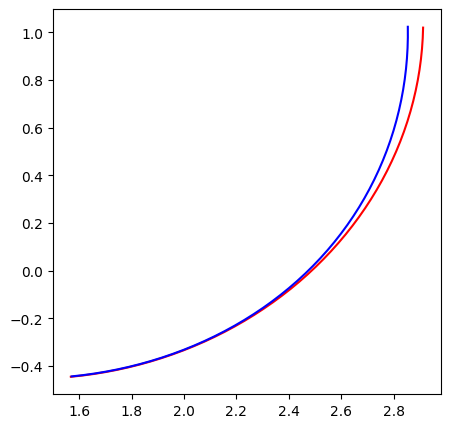

In [10]:
import torch

learner.load_state_dict(torch.load(f"{TrainerConfig.ckpt_path}/state.pth"))
test_data = UnicycleDataset.generate_test_data(robot)

learner.test_traj(test_data)